# Time Series Visualization - Single Dataset
Sensor-Daten vs. Gelenkwinkel über die Zeit

In [17]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("✓ Libraries loaded")

✓ Libraries loaded


In [18]:
# === GIB DEN DATENSATZ EIN ===
# Beispiel: "runs/2026-02-11_17-22-11/merged.csv"

file_path = "runs/2026-02-19_10-14-37/merged_smoothed.csv"
#"runs/2026-02-16_15-19-31/merged_smoothed.csv"
#"runs/2026-02-19_10-14-37/merged_smoothed.csv"
#"runs/2026-02-11_17-22-11/merged.csv"
#"runs/2026-02-05_14-46-22/merged_smoothed.csv" #Gut
#"runs/2026-02-06_14-14-43/merged.csv" Ok viele Artifakte am anfang
#"runs/2026-02-09_12-34-53/merged.csv" Nicht Sehr gut 
#"runs/2026-02-10_12-14-57/merged.csv"Gut


# Lade Datei
if not Path(file_path).exists():
    print(f"❌ Datei nicht gefunden: {file_path}")
    print(f"\nVerfügbare Datensätze:")
    for f in sorted(Path("runs").glob("*/merged.csv"), reverse=True)[:5]:
        print(f"  - {f.parent.name}")
else:
    print(f"✓ Lade: {file_path}")
    df = pl.read_csv(file_path)
    
    # Falls noch pivotiert werden muss (sensor_id Spalte existiert)
    if "sensor_id" in df.columns:
        print("  → Pivot sensor_id...")
        sensor_ids = sorted(df["sensor_id"].unique().to_list())
        num_samples = len(df) // len(sensor_ids)
        
        sample_ids = np.arange(len(df)) // len(sensor_ids)
        df = df.with_columns(pl.Series("sample_id", sample_ids))
        
        # Pivot Sensordaten
        sensor_features = [c for c in df.columns if c in ["magX", "magY", "magZ", "accX", "accY", "accZ"]]
        pivoted = df.select(["sample_id", "sensor_id"] + sensor_features).pivot(
            values=sensor_features,
            index="sample_id",
            on="sensor_id",
            aggregate_function="mean"
        ).sort("sample_id")
        
        # Get targets (Gelenkwinkel)
        theta_cols = [c for c in df.columns if c.startswith("theta_")]
        targets = df.group_by("sample_id", maintain_order=True).agg(
            [pl.col(c).mean() for c in theta_cols]
        ).sort("sample_id")
        
        # Join
        df = pivoted.join(targets, on="sample_id", how="inner").to_pandas()
    else:
        df = df.to_pandas()
    
    print(f"✓ Shape: {df.shape[0]} samples × {df.shape[1]} columns")
    
    # Identifiziere Spalten
    theta_cols = [c for c in df.columns if c.startswith("theta_")]
    
    # Extrahiere Sensor-IDs aus Sensorspalten
    sensor_cols = [c for c in df.columns if any(c.startswith(f"{prefix}_") for prefix in ["magX", "magY", "magZ", "accX", "accY", "accZ"])]
    sensor_ids = sorted(set([int(c.split('_')[-1]) for c in sensor_cols]))
    
    print(f"✓ Gelenke: {len(theta_cols)} | Sensoren: {len(sensor_ids)}")
    if sensor_ids:
        print(f"  Sensor-IDs: {sensor_ids[:6]}{'...' if len(sensor_ids) > 6 else ''}")
    
    # Berechne Magnitudes falls nötig
    for sid in sensor_ids:
        if all(f"mag{ax}_{sid}" in df.columns for ax in ['X', 'Y', 'Z']):
            df[f"magMag_{sid}"] = np.sqrt(df[f"magX_{sid}"]**2 + df[f"magY_{sid}"]**2 + df[f"magZ_{sid}"]**2)

✓ Lade: runs/2026-02-19_10-14-37/merged_smoothed.csv
  → Pivot sensor_id...
✓ Shape: 6728 samples × 50 columns
✓ Gelenke: 13 | Sensoren: 6
  Sensor-IDs: [0, 1, 2, 3, 4, 5]


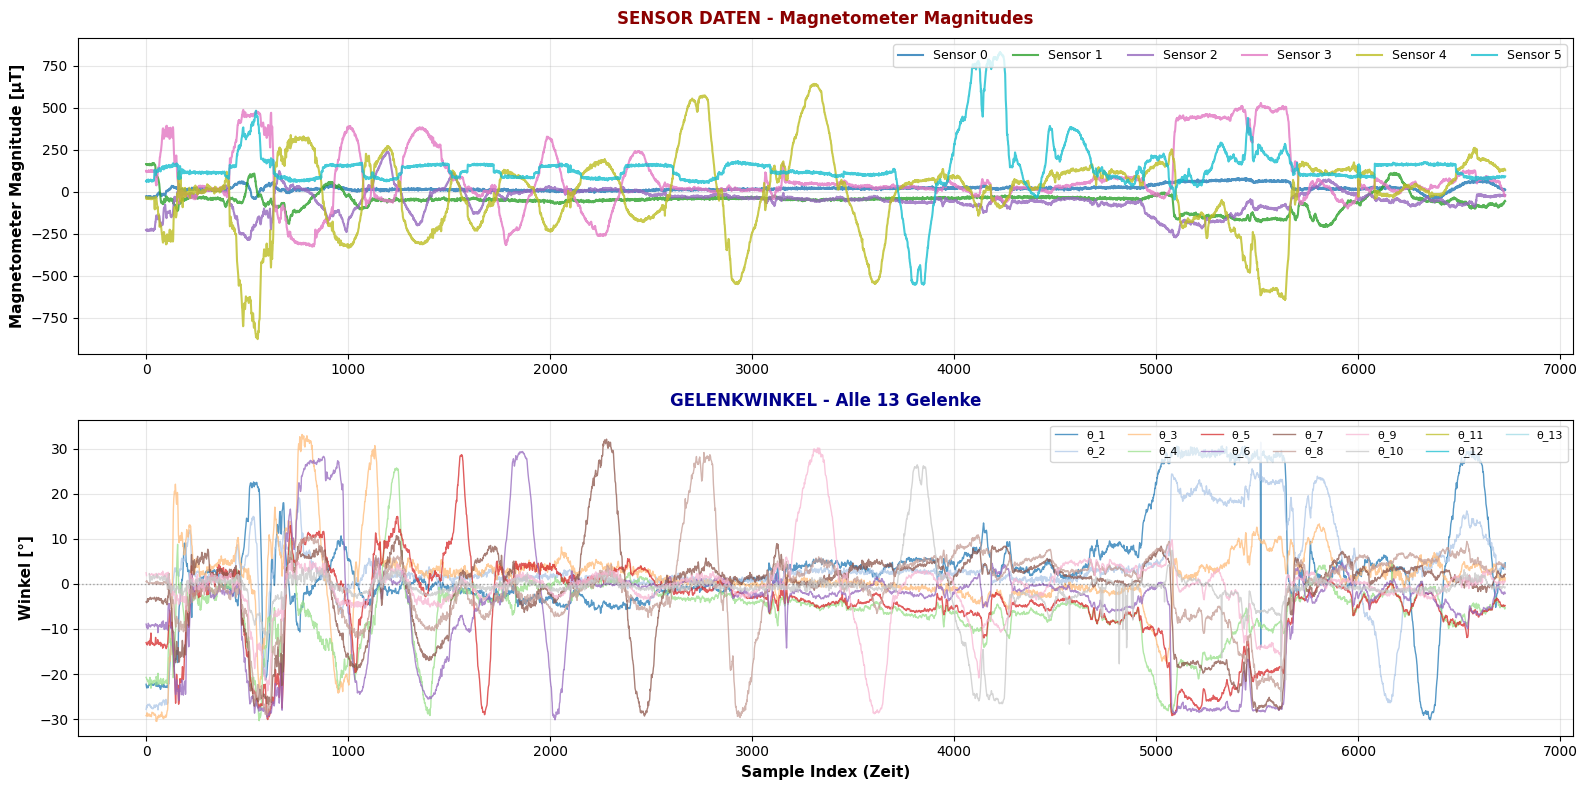

✓ Visualisierung erstellt


In [19]:
# === HAUPTVISUALISIERUNG (KOMPAKT) ===

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# ===== PLOT 1: ALLE SENSOR-MAGNITUDES ÜBEREINANDER =====
ax = axes[0]
colors_sensors = plt.cm.tab10(np.linspace(0, 1, len(sensor_ids)))

for idx, sid in enumerate(sensor_ids):
    if f"magMag_{sid}" in df.columns:
        ax.plot(df[f"magX_{sid}"], label=f'Sensor {sid}', linewidth=1.5, alpha=0.8, color=colors_sensors[idx])

ax.set_ylabel("Magnetometer Magnitude [μT]", fontweight='bold', fontsize=11)
ax.set_title("SENSOR DATEN - Magnetometer Magnitudes", fontweight='bold', fontsize=12, color='darkred', pad=10)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', ncol=len(sensor_ids), fontsize=9)

# ===== PLOT 2: ALLE GELENKWINKEL ÜBEREINANDER =====
ax = axes[1]
colors_joints = plt.cm.tab20(np.linspace(0, 1, len(theta_cols)))

for idx, col in enumerate(theta_cols):
    ax.plot(df[col], label=f'θ_{idx+1}', linewidth=1, alpha=0.75, color=colors_joints[idx])

ax.axhline(y=0, color='black', linestyle=':', alpha=0.3, linewidth=1)
ax.set_ylabel("Winkel [°]", fontweight='bold', fontsize=11)
ax.set_xlabel("Sample Index (Zeit)", fontweight='bold', fontsize=11)
ax.set_title("GELENKWINKEL - Alle 13 Gelenke", fontweight='bold', fontsize=12, color='darkblue', pad=10)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', ncol=7, fontsize=8)

plt.tight_layout()
plt.show()
print("✓ Visualisierung erstellt")

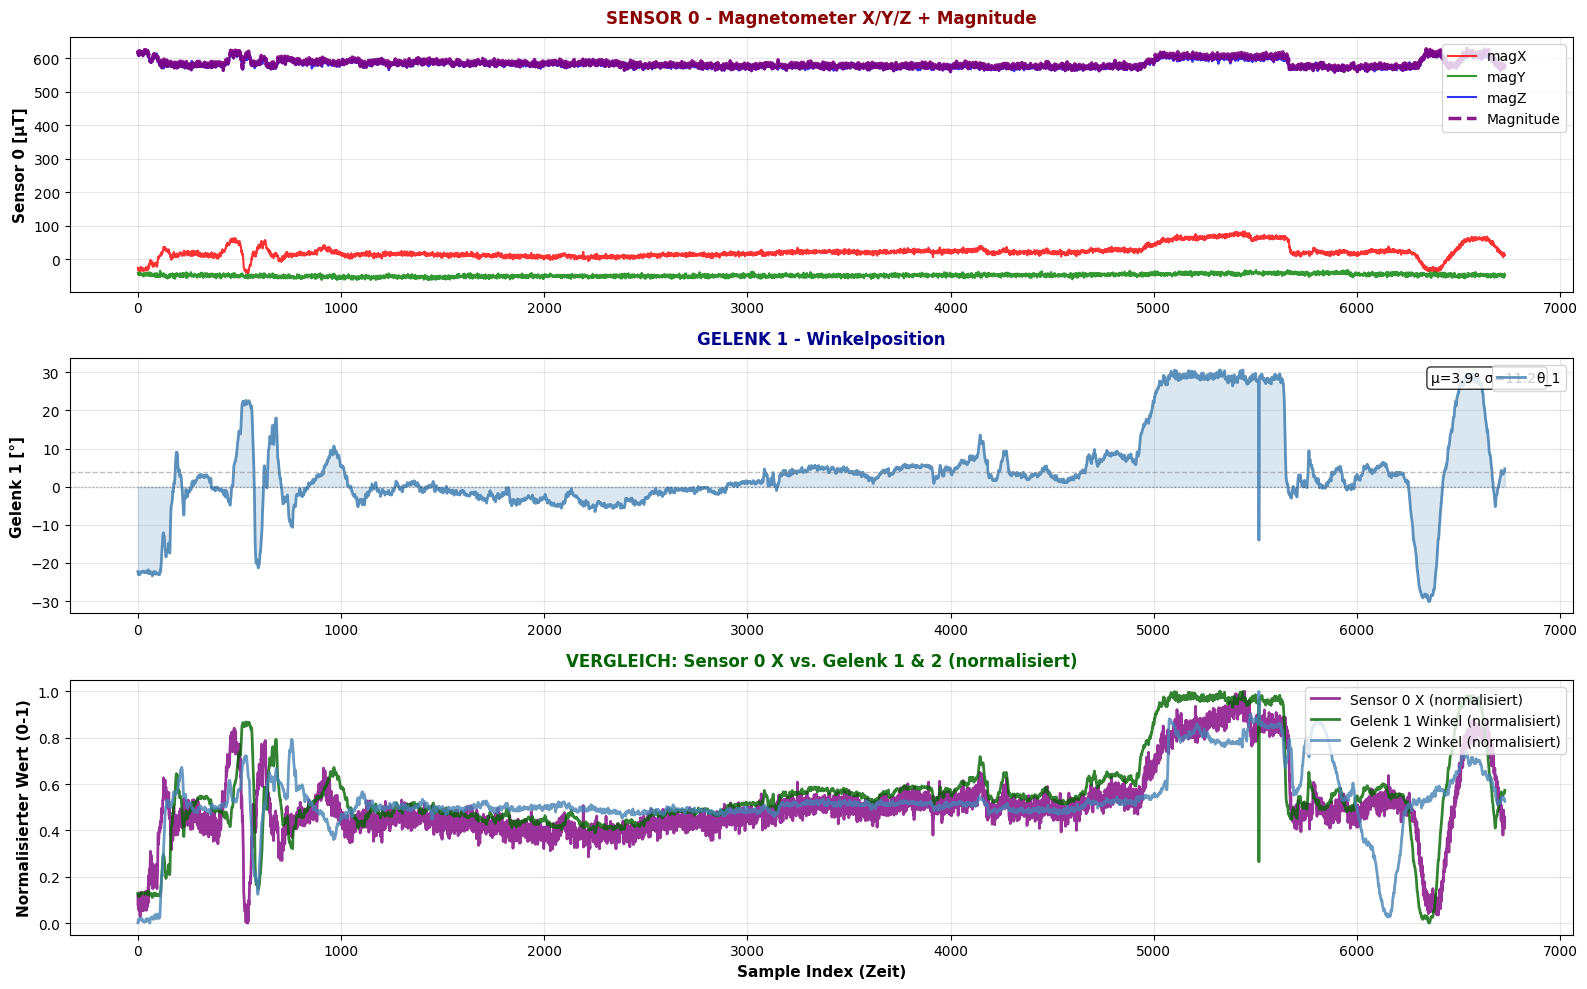

✓ Fokus-Visualisierung erstellt


: 

In [ ]:
# === FOKUS: SENSOR 0 vs. GELENK 1 ===

fig, axes = plt.subplots(3, 1, figsize=(16, 10))

# ===== PLOT 1: Sensor 0 - magX, magY, magZ =====
ax = axes[0]
if f"magX_0" in df.columns:
    ax.plot(df[f"magX_0"], label="magX", linewidth=1.5, alpha=0.8, color='red')
    ax.plot(df[f"magY_0"], label="magY", linewidth=1.5, alpha=0.8, color='green')
    ax.plot(df[f"magZ_0"], label="magZ", linewidth=1.5, alpha=0.8, color='blue')
if f"magMag_0" in df.columns:
    ax.plot(df[f"magMag_0"], label="Magnitude", linewidth=2.5, alpha=0.9, color='purple', linestyle='--')

ax.set_ylabel("Sensor 0 [μT]", fontweight='bold', fontsize=11)
ax.set_title("SENSOR 0 - Magnetometer X/Y/Z + Magnitude", fontweight='bold', fontsize=12, color='darkred', pad=10)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=10)

# ===== PLOT 2: Gelenk 1 =====
ax = axes[1]
if "theta_1" in df.columns:
    ax.plot(df["theta_1"], label="θ_1", linewidth=2, alpha=0.85, color='steelblue')
    ax.fill_between(range(len(df)), df["theta_1"], alpha=0.2, color='steelblue')
    ax.axhline(y=0, color='black', linestyle=':', alpha=0.3, linewidth=1)
    
    mean_val = df["theta_1"].mean()
    std_val = df["theta_1"].std()
    ax.axhline(y=mean_val, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    ax.text(0.98, 0.95, f"μ={mean_val:.1f}° σ={std_val:.1f}°", 
            transform=ax.transAxes, fontsize=10, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_ylabel("Gelenk 1 [°]", fontweight='bold', fontsize=11)
ax.set_title("GELENK 1 - Winkelposition", fontweight='bold', fontsize=12, color='darkblue', pad=10)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=10)

# ===== PLOT 3: Sensor 0 X vs Gelenk 1 & 2 (normalisiert) =====
ax = axes[2]
if f"magX_0" in df.columns and "theta_1" in df.columns and "theta_2" in df.columns:
    # Normalisiere auf 0-1 für Vergleich
    mag_norm = (df[f"magX_0"] - df[f"magX_0"].min()) / (df[f"magX_0"].max() - df[f"magX_0"].min())
    theta2_norm = (df["theta_1"] - df["theta_1"].min()) / (df["theta_1"].max() - df["theta_1"].min())
    theta3_norm = (df["theta_2"] - df["theta_2"].min()) / (df["theta_2"].max() - df["theta_2"].min())
    
    ax.plot(mag_norm, label="Sensor 0 X (normalisiert)", linewidth=2, alpha=0.8, color='purple')
    ax.plot(theta2_norm, label="Gelenk 1 Winkel (normalisiert)", linewidth=2, alpha=0.8, color='darkgreen')
    ax.plot(theta3_norm, label="Gelenk 2 Winkel (normalisiert)", linewidth=2, alpha=0.8, color='steelblue')
ax.set_ylabel("Normalisierter Wert (0-1)", fontweight='bold', fontsize=11)
ax.set_xlabel("Sample Index (Zeit)", fontweight='bold', fontsize=11)
ax.set_title("VERGLEICH: Sensor 0 X vs. Gelenk 1 & 2 (normalisiert)", fontweight='bold', fontsize=12, color='darkgreen', pad=10)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.show()
print("✓ Fokus-Visualisierung erstellt")